<a href="https://colab.research.google.com/github/chaeun6-cmd/New-repository/blob/main/MainQuest_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (35.6 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direct

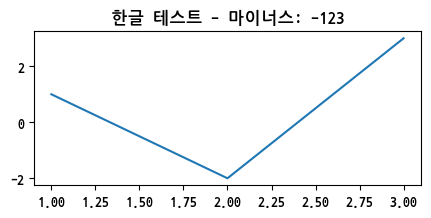

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm

from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score
)
from sklearn.model_selection import cross_val_score, KFold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance, partial_dependence

import warnings
warnings.filterwarnings('ignore')

# Colab: 한글 폰트 설치 및 설정 + 마이너스 부호 깨짐 방지
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -r

# 1) 한글 폰트 설치 (Nanum + Noto CJK)
!apt-get -qq update > /dev/null
!apt-get -qq -y install fonts-nanum fonts-noto-cjk > /dev/null
!fc-cache -fv > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import os, glob

# 2) 설치된 한글 폰트 파일(ttf/ttc) 경로 찾기
candidates = []
candidates += glob.glob("/usr/share/fonts/truetype/nanum/*.ttf")
candidates += glob.glob("/usr/share/fonts/opentype/noto/*.ttc")
candidates += glob.glob("/usr/share/fonts/truetype/noto/*.ttf")

# 우선순위: NanumGothic -> NotoSansCJKkr(또는 유사)
preferred = None
for p in candidates:
    name = os.path.basename(p).lower()
    if "nanumgothic" in name:
        preferred = p
        break
if preferred is None:
    for p in candidates:
        name = os.path.basename(p).lower()
        if ("notosanscjk" in name and "kr" in name) or ("notosans" in name and "cjk" in name):
            preferred = p
            break
if preferred is None and candidates:
    preferred = candidates[0]

print("선택된 폰트 파일:", preferred)

# 3) Matplotlib에 폰트 파일로 강제 등록/설정
if preferred:
    fm.fontManager.addfont(preferred)
    font_name = fm.FontProperties(fname=preferred).get_name()
    mpl.rcParams["font.family"] = font_name

# 4) 마이너스(−) 깨짐 방지
mpl.rcParams["axes.unicode_minus"] = False

# 5) 테스트
plt.figure(figsize=(5,2))
plt.title("한글 테스트 - 마이너스: -123")
plt.plot([1,2,3],[1,-2,3])
plt.show()



#데이터 합치기

In [5]:
import pandas as pd

files = [
    '2019-Oct.csv',
    '2019-Nov.csv',
    '2019-Dec.csv',
    '2020-Jan.csv',
    '2020-Feb.csv'
]

df_list = [pd.read_csv(f) for f in files]
df = pd.concat(df_list, ignore_index=True)

df.shape

(20692840, 9)

#데이터 전처리

In [6]:
#기본 구조 확인
df.info()
df.head()

#결측치 확인
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20692840 entries, 0 to 20692839
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 1.4+ GB


,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,20339246
brand,8757117
price,0
user_id,0
user_session,4598


**1. event_time**: 이벤트 발생 시간 (시간대 분석 및 리텐션 트렌드 분석 가능)

**2. event_type**: 사용자 행동 유형 (상품 조회-장바구니 분석-구매로 이어지는 지 분석 가능)

**3. product_id**: 상품 id (인기 상품 분석 가능)

**4. category_id**: 상품 카테고리 id (카테고리별 매출)

**5. category_code**: 카테고리 코드 - 결측값이 너무 많음

**6. brand**:  브랜드 (브랜드별 매출 및 고객 브랜도 선호도 분석 가능) - 결측값 존재

**7. price**: 가격 (총 매출 및 평균 구매 금액 분석 가능)

**8. user_id**: 사용자 id (리텐션, 신규-장기 고객 전환율, 유저 행동 분석)

**9. user_session**: 방문 단위 (세션에서 얼마나 머무는지, 세션별 행동 분석)

In [8]:
#결측치 많은 'category_code' 제거
df = df.drop(columns=['category_code'])

df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id', 'brand',
       'price', 'user_id', 'user_session'],
      dtype='object')

In [9]:
#'event_time' 타입 변환
df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')

In [10]:
#'event_time' datetime으로 변환했을 때 비정상적인 값 발생 -> NaT 처리 -> 제거
df = df.dropna(subset=['event_time'])

In [11]:
#이상치 처리
df = df[df['price'] > 0]

In [12]:
#중복 제거
df = df.drop_duplicates()

#EDA

**분석 목적**

이 데이터(이벤트 로그 기반 데이터)는 단순히 서비스 유지가 아닌, "사용자가 어떤 행동 흐름에 거쳐 구매로 이어지는지"가 목표.

In [13]:
# 퍼널 분석용 변수(숫자 형태의 타입으로 변환)
df['is_view'] = (df['event_type'] == 'view').astype(int)
df['is_cart'] = (df['event_type'] == 'cart').astype(int)
df['is_purchase'] = (df['event_type'] == 'purchase').astype(int)

# 날짜 (추가 시각화용)
df['date'] = df['event_time'].dt.date

In [14]:
#퍼널 데이터 집계(단계별 이벤트 수 산출 -> 사용자 행동 분석)
funnel = df['event_type'].value_counts()

view = funnel.get('view', 0)
cart = funnel.get('cart', 0)
purchase = funnel.get('purchase', 0)

print("view:", view)
print("cart:", cart)
print("purchase:", purchase)

view: 9626299
cart: 5615633
purchase: 1285982


In [15]:
#전환율 계산(장바구니 -> 결제로 이어진 유저 수 계)
view_to_cart = cart / view
cart_to_purchase = purchase / cart

print("view → cart 전환율:", round(view_to_cart, 4))
print("cart → purchase 전환율:", round(cart_to_purchase, 4))

view → cart 전환율: 0.5834
cart → purchase 전환율: 0.229


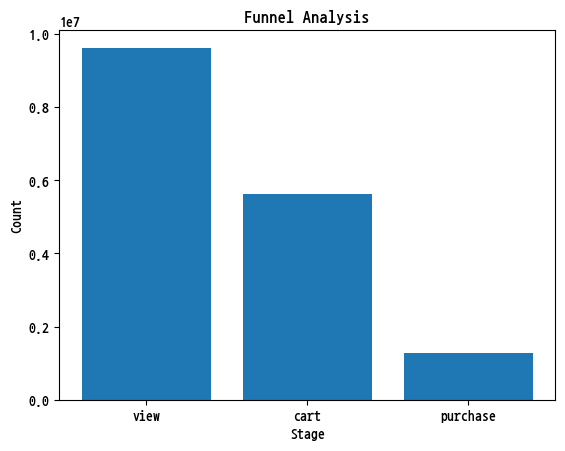

In [16]:
#시각화 자료(퍼널 분석 막대 그래프)
import matplotlib.pyplot as plt

#퍼널 단계/해당 수치 정의
labels = ['view', 'cart', 'purchase']
values = [view, cart, purchase]

#각 단계별 사용자 수 막대그래프로 표현
plt.figure()
plt.bar(labels, values)
plt.title('Funnel Analysis')
plt.xlabel('Stage')
plt.ylabel('Count')
plt.show()

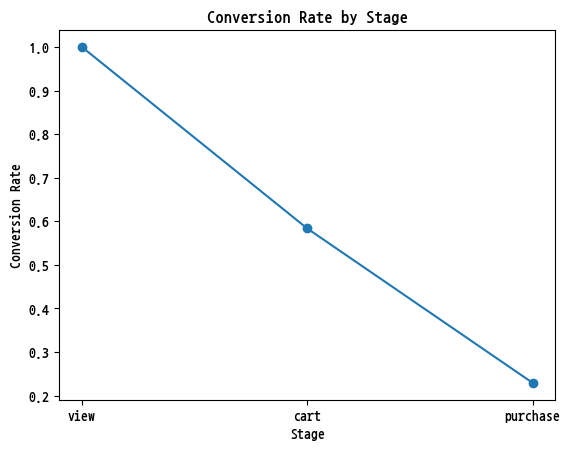

In [17]:
#시각화 자료(전환율 표시)
conversion_rates = [1, view_to_cart, cart_to_purchase]

#유저 단계별로 줄어드는 흐름 보여주는 시각화 자료
plt.figure()
plt.plot(labels, conversion_rates, marker='o')
plt.title('Conversion Rate by Stage')
plt.xlabel('Stage')
plt.ylabel('Conversion Rate')
plt.show()

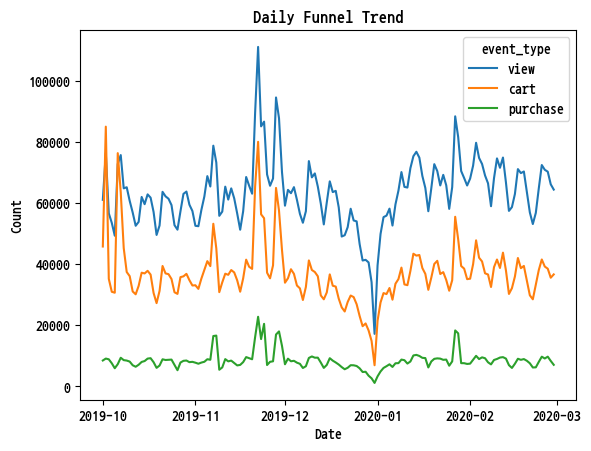

In [18]:
#날짜별/이벤트 발생 횟수 집
daily_funnel = df.groupby(['date', 'event_type']).size().unstack(fill_value=0)

#날짜별로 view-cart-purchase
daily_funnel[['view', 'cart', 'purchase']].plot()

#시간에 따른 퍼널 변
plt.title('Daily Funnel Trend')
plt.xlabel('Date')
plt.ylabel('Count')
plt.show()

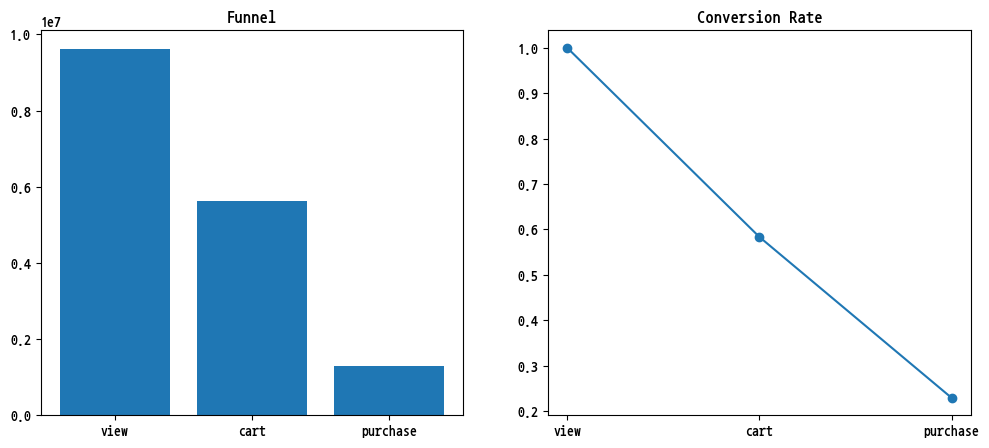

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
#유저의 이탈과 단계별 전환율을 동시에 보여주는 시각화 자료
# 퍼널
axes[0].bar(['view','cart','purchase'], [view, cart, purchase])
axes[0].set_title('Funnel')

# 전환율
axes[1].plot(['view','cart','purchase'], [1, view_to_cart, cart_to_purchase], marker='o')
axes[1].set_title('Conversion Rate')

plt.show()

#심화 분석

In [20]:
#핵심 수치 출력
print(f"view → cart 전환율: {view_to_cart:.2%}")
print(f"cart → purchase 전환율: {cart_to_purchase:.2%}")

view → cart 전환율: 58.34%
cart → purchase 전환율: 22.90%


**⭐ 핵심 인사이트**

view → cart(58.60%) 수치는 매우 높은 편이지만,

cart → purchase(22.24%)는 상대적으로 낮다.

병목 지점(Bottleneck) ->  **"장바구니에는 잘 담는데, 막상 결제는 망설인다"**

In [21]:
# 사용자(user_id)와 세션(user_session)별로 시간(event_time) 순서대로 정렬
df = df.sort_values(by=['user_id', 'user_session', 'event_time'])

# 각 행의 바로 이전 이벤트가 무엇이었는지 'prev_event' 컬럼 생성
df['prev_event'] = df.groupby(['user_id', 'user_session'])['event_type'].shift(1)

In [22]:
# 이전 이벤트와의 시간 차이 계산 (초 단위)
df['prev_time'] = df.groupby(['user_id', 'user_session'])['event_time'].shift(1)
df['duration'] = (df['event_time'] - df['prev_time']).dt.total_seconds()

# 예: 'cart'에서 'purchase'로 넘어간 데이터만 필터링 -> 평균 고민 시간 산출
cart_to_purchase_time = df[(df['prev_event'] == 'cart') & (df['event_type'] == 'purchase')]
print(f"평균 결제 고민 시간: {cart_to_purchase_time['duration'].mean():.2f}초")

평균 결제 고민 시간: 3476.72초


**⭐ 핵심 인사이트**

**장바구니에서 구매로 이어지기까지 평균 약 59분이 소요된다는 사실을 알 수 있음.**

In [23]:
# 각 세션별 마지막 이벤트만 추출
last_events = df.groupby('user_session').tail(1)

# 구매가 일어나지 않은 세션만 필터링
churned_sessions = last_events[last_events['event_type'] != 'purchase']

# 이탈 직전 가장 많이 한 행동 순위
print(churned_sessions['event_type'].value_counts())

event_type
view                3690451
cart                 502443
remove_from_cart     186600
Name: count, dtype: int64


**⭐ 핵심 인사이트**

**1. view(약 266만 명)**: 대부분 유저(view)가 상품만 보고 떠남.

**2. cart(약 37만 명)**: 장바구니까지 가지만, 구매까지 안 감.

**3. remove_from_cart(약 13만 명)**: 경쟁 상품과 비교 후, 구매는 포기. 역시 구매까지 안 감.

**즉, 상품의 매력도나 상품 탐색의 편의성 문제일 수 있다는 예측을 해볼 수 있다.**

In [24]:
#행동의 반복성 확인
# 유저별, 상품별(product_id) 조회(view) 횟수 계산
view_counts = df[df['event_type'] == 'view'].groupby(['user_id', 'product_id']).size().reset_index(name='view_cnt')

# 실제 구매 여부와 결합 (Left Join)
purchase_flag = df[df['event_type'] == 'purchase'][['user_id', 'product_id']].drop_duplicates()
purchase_flag['is_purchased'] = 1

view_analysis = pd.merge(view_counts, purchase_flag, on=['user_id', 'product_id'], how='left').fillna(0)

# 조회 횟수별 구매 전환율 확인
print(view_analysis.groupby('view_cnt')['is_purchased'].mean())

view_cnt
1      0.050294
2      0.111535
3      0.167934
4      0.208225
5      0.239542
         ...   
259    0.000000
279    1.000000
299    0.000000
314    0.000000
321    0.000000
Name: is_purchased, Length: 176, dtype: float64


**⭐ 핵심 인사이트**

상품을 여러 번 조회한 유저일수록 구매로 이어질 확률이 증가함.

#심화 분석 기법(퍼널 분석-유저 기준)

In [25]:
import plotly.graph_objects as go

# 유저 기준 퍼널
view_users = df[df['event_type']=='view']['user_id'].nunique()
cart_users = df[df['event_type']=='cart']['user_id'].nunique()
purchase_users = df[df['event_type']=='purchase']['user_id'].nunique()

stages = ["상품 조회(View)", "장바구니(Cart)", "구매 완료(Purchase)"]
values = [view_users, cart_users, purchase_users]

fig = go.Figure(go.Funnel(
    y=stages,
    x=values,
    textinfo="value+percent initial",
    marker={"color": ["#E5ECF6", "#AB63FA", "#19D3F3"]}
))

fig.update_layout(title_text='전체 커머스 퍼널 및 전환율 분석')
fig.show()

#결제 시간 분석

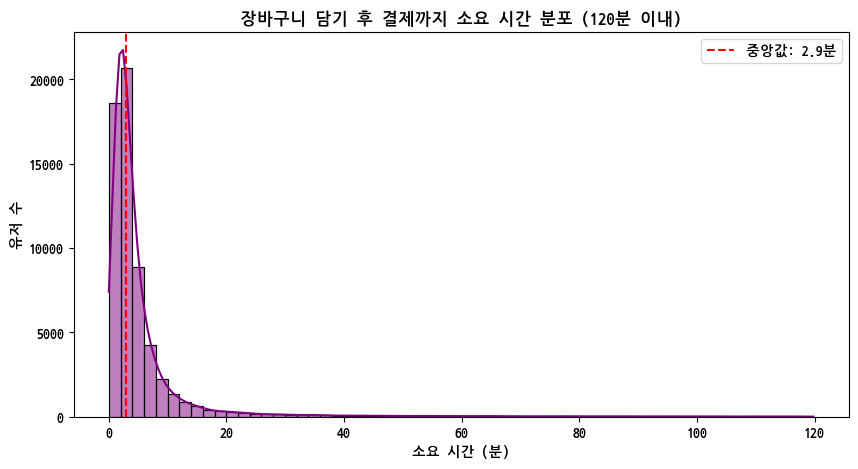

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# NaN 제거 (중요 ⭐)
pay_time_min = (cart_to_purchase_time['duration'] / 60).dropna()

# 중앙값 미리 계산
median_val = pay_time_min.median()

plt.figure(figsize=(10, 5))

sns.histplot(pay_time_min[pay_time_min < 120], bins=60, kde=True, color='purple')

plt.axvline(median_val, color='red', linestyle='--',
            label=f'중앙값: {median_val:.1f}분')

plt.title('장바구니 담기 후 결제까지 소요 시간 분포 (120분 이내)')
plt.xlabel('소요 시간 (분)')
plt.ylabel('유저 수')
plt.legend()

plt.show()

#반복 행동 분석

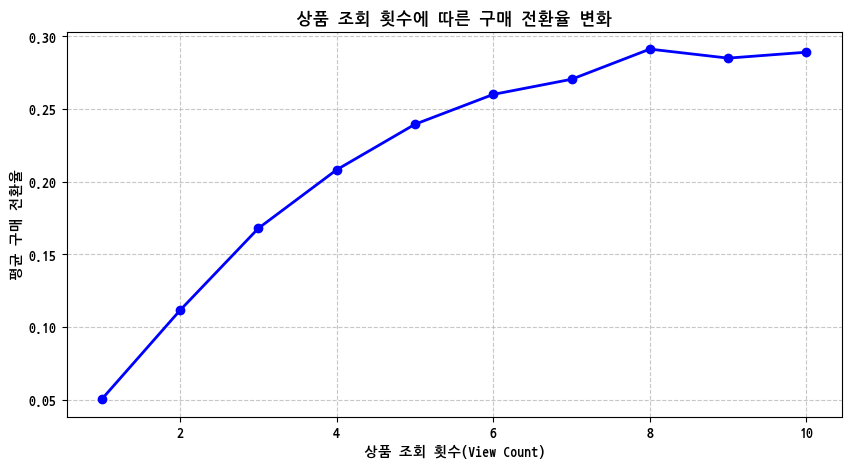

In [27]:
# 정렬
conversion_by_view = view_analysis.groupby('view_cnt')['is_purchased'].mean()
conversion_by_view = conversion_by_view.sort_index()

plt.figure(figsize=(10, 5))

conversion_by_view[:10].plot(
    kind='line',
    marker='o',
    color='blue',
    linewidth=2
)

plt.title('상품 조회 횟수에 따른 구매 전환율 변화')
plt.xlabel('상품 조회 횟수(View Count)')
plt.ylabel('평균 구매 전환율')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#인사이트 정리 및 제안
**1. 분석 목표**

: 본 분석은 화장품 쇼핑몰 데이터. 즉, 이커머스 이벤트 로그 데이터를 기반으로 사용자 행동 흐름(view → cart → purchase)을 분석하여 전환 과정에서의 병목 구간을 파악하는 것이 목표.

-“Activation 및 Revenue 단계에 집중하여 분석 실행.


**2. 전처리**

: 결측치 확인 및 제거. 이상치 확인 및 중복 제거 완료.

퍼널 분석을 위해 event_type 기반 파생 변수를 생성.


**3. 퍼널 분석**

: 퍼설 분석 통해서 전체 유저 중 전환율 및 이탈 확인을 시각화 자료 통해 가능.

**4. 심화 분석 정리**

: 유저 이탈 분석 및 반복 행동 분석

**5. 인사이트**

- “view" 단계에서 "cart"로의 전환율이 낮아 초기 관심 유도 단계에서 큰 이탈이 발생.

- 상품 조회 횟수가 증가할수록 구매 확률이 상승하는 경향이 나타나며, 반복 노출이 구매 결정에 중요한 영향을 미치는 것을 확인.


**6. 제언**

1) 반복 노출을 통한 구매 확신 부여 (Retargeting)

데이터 근거: 상품 조회 횟수가 많을수록 구매 확률이 상승함.

실행 방안: 유저가 한 번 조회한 상품을 메인 페이지의 '최근 본 상품' 영역이나 하단 배너에 지속적으로 노출하는 개인화 UI를 강화.

장바구니에 담고 결제하지 않은 유저에게 해당 상품의 리뷰나 평점 정보를 푸시 알림으로 보내어 '조회 횟수'를 인위적으로 늘려서 구매 확신.

2)  초기 이탈 방지를 위한 상세 페이지 개선 (UX Optimization)

데이터 근거: 'View'에서 'Cart'로 넘어가는 단계에서 가장 큰 이탈이 발생함.

실행 방안: 상품 상세 페이지 상단에 '첫 구매 할인 쿠폰'이나 '무료 배송 혜택' 등을 눈에 띄게 배치 -> 장바구니 담기 버튼을 누를 유인을 제공.

예를 들어 뷰티 제품 특성상 피부 타입별 가이드를 제공하여 유저의 고민 시간을 줄여주는 것이 필요.


3) 개인화 추천 시스템 도입을 통한 체류 시간 증대

데이터 근거: 여러 상품을 비교 조회하는 과정이 구매로 이어지는 트리거가 됨.

실행 방안: 특정 상품 조회 시 유사한 성분이나 가격대의 다른 제품을 하단에 추천.

유저가 사이트 내에서 더 많은 상품을 탐색(View 증가)하게 유도함으로써 최종 구매 확률을 높이기.
